## Neural Networks

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Reading the dataset

In [41]:
df = pd.read_csv('spiral.csv')

In [42]:
df.head()

,x1,x2,y
0,0.000000,0.000000,0
1,-0.000650,0.010080,0
2,0.009809,0.017661,0
3,0.007487,0.029364,0
4,-0.000027,0.040404,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      300 non-null    float64
 1   x2      300 non-null    float64
 2   y       300 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 7.2 KB


#### Visualizing the target attribute

In [44]:
df['y'].value_counts()

y
0    100
1    100
2    100
Name: count, dtype: int64

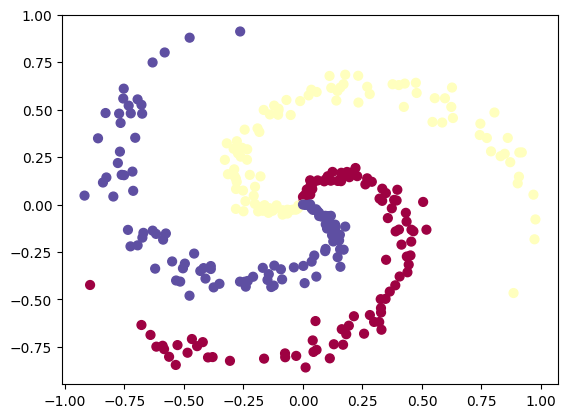

In [45]:
plt.scatter(df["x1"], df["x2"], c=df["y"], s=40, cmap=plt.cm.Spectral)
plt.show()

#### Dividing the data into input (X) and output (Y)

In [46]:
X = df.drop('y', axis=1).to_numpy()

In [47]:
X[:5]

array([[ 0.00000000e+00,  0.00000000e+00],
       [-6.50123964e-04,  1.00800667e-02],
       [ 9.80910862e-03,  1.76607760e-02],
       [ 7.48711824e-03,  2.93635268e-02],
       [-2.71404625e-05,  4.04040313e-02]])

In [48]:
X.shape

(300, 2)

In [49]:
y = df['y'].to_numpy()

In [50]:
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

#### Initializing the parameters

In [51]:
# datapoints
m = X.shape[0]
m

300

In [52]:
# features
d = X.shape[1]
d

2

In [53]:
np.unique(y)

array([0, 1, 2], dtype=int64)

In [54]:
# total no. of classes
n = len(np.unique(y))
n

3

- input matrix = mxd (300x2)
- weight matrix = dxn (2x3)
- bias matrix = 1xn (1x3)
- output matrix = mxn (300x3)

#### Initialize the weight and bias matrices to calculate z

In [55]:
W = 0.01 * np.random.randn(d,n)
b = np.zeros((1,n))

In [56]:
W

array([[-0.00213531, -0.00687178,  0.00530767],
       [-0.00186721, -0.0139589 , -0.01409633]])

In [57]:
b

array([[0., 0., 0.]])

In [58]:
z = np.dot(X, W) + b
z.shape    

(300, 3)

In [59]:
z[:10]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.74333748e-05, -1.36239151e-04, -1.45542537e-04],
       [-5.39218115e-05, -3.13931056e-04, -1.96888569e-04],
       [-7.08151287e-05, -4.61332400e-04, -3.74178697e-04],
       [-7.53848082e-05, -5.63809395e-04, -5.69692412e-04],
       [-1.09105742e-04, -7.48286133e-04, -6.64900840e-04],
       [-1.62836973e-04, -9.40741669e-04, -5.77396169e-04],
       [-1.76509864e-04, -1.09461557e-03, -8.02373956e-04],
       [-1.82067988e-04, -1.21561950e-03, -1.03160046e-03],
       [-2.36674826e-04, -1.41429708e-03, -9.49942860e-04]])

#### Applying the activation function - Softmax Classifier

In [60]:
exp_z = np.exp(z)
exp_z.shape

(300, 3)

In [61]:
prob = exp_z/(np.sum(exp_z, axis=1, keepdims=True))
prob[:5]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33336077, 0.33332117, 0.33331807],
       [0.33337811, 0.33329144, 0.33333045],
       [0.33341044, 0.33328026, 0.33330931],
       [0.33344253, 0.33327971, 0.33327775]])

In [62]:
prob.shape

(300, 3)

In [63]:
y.shape

(300,)

#### Calculating the loss (Categorical Cross Entropy Loss)

In [64]:
def loss(y, prob):
    m = y.shape[0]
    error = - np.log(prob[range(m),y])
    return np.sum(error)/m
    
loss(y, prob)

1.1006415338112148

### Backpropagation

- $ w_n = w_o - lr*\frac{∂L}{∂w}$
- $ w_n = w_o - lr*\frac{∂L}{∂b}$

#### Calculating the gradient of the loss function

**1. with respect to the probabilities**  - $ \frac{∂J}{∂z} = dZ = [P_k - I]$

In [65]:
dZ = prob             # dZ = probabilities of class
dZ[range(m),y] -= 1   # This is same as indicator function - pk-I

In [66]:
dZ.shape

(300, 3)

In [67]:
X.shape

(300, 2)

**2. with respect to the weights** - $ \frac{∂z}{∂w} = \frac{∂(WX+b)}{∂w} = X$

In [68]:
dW = np.dot(X.T, dZ)     # dJ/dw = dW
dW

array([[-11.9695436 , -16.46932093,  28.43886453],
       [ 26.55595113, -30.78153476,   4.22558363]])

**3. with respect to the bias**

In [69]:
db = dZ

In [70]:
db.shape

(300, 3)

In [71]:
db = np.sum(dz, axis=0, keepdims=True)
db.shape

(1, 3)

In [72]:
db

array([[-100.02241405,  -99.9985435 ,  -99.97904245]])

#### Weight Updation

In [73]:
lr = 0.1
W += -lr * dW
b += -lr * db

-----

### Combining all the steps together

In [74]:
max_iters = 500
lr = 1

d = X.shape[1]
n = len(np.unique(y))
m = X.shape[0]
W = 0.01 * np.random.randn(d,n)
b = np.zeros((1,n))
loss_history = []

for i in range(max_iters):
    
    # evaluate the class probs
    z = np.dot(X, W) + b
    exp_z = np.exp(z)
    probs = exp_z/np.sum(exp_z, axis=1, keepdims=True)

    # compute the loss: average cross-entropy loss
    error = -np.log(probs[range(m), y])
    loss = np.sum(error)/m
    loss_history.append(loss)

    # compute the gradient on score
    dZ = probs
    dZ[range(m),y] -= 1
    dZ = dZ/m
    dW = np.dot(X.T, dZ)
    db = np.sum(dZ, axis=0, keepdims=True)

    # perform a parameter update using gradient descent
    W += -lr * dW
    b += -lr * db


In [75]:
loss_history[-10:]

[0.7401830100980594,
 0.7401830001519221,
 0.7401829904285653,
 0.7401829809229913,
 0.7401829716303143,
 0.7401829625457587,
 0.7401829536646561,
 0.7401829449824432,
 0.7401829364946593,
 0.7401829281969434]